In [6]:
# STEP 1: IMPORT ALL LIBRARIES & CONFIGURE STYLES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) 

In [10]:
# STEP 2: LOAD DATASET 
try:
    print("Fetching California Housing Dataset via scikit-learn...")
    california = fetch_california_housing(as_frame=True)
    df_house = california.frame
    X = df_house.drop(columns=['MedHouseVal'])
    y = df_house['MedHouseVal']
    print("Dataset built successfully!")
except Exception as e:
    print("scikit-learn SSL error detected. Activating secure backup mirror download...")
    
    mirror_url = "/Users/priyangshubagchi/Downloads/housing 3.csv"
    df_mirror = pd.read_csv(mirror_url)
    
    df_mirror = df_mirror.rename(columns={
        'longitude': 'Longitude', 'latitude': 'Latitude',
        'housing_median_age': 'HouseAge', 'total_rooms': 'AveRooms',
        'total_bedrooms': 'AveBedrms', 'population': 'Population',
        'households': 'Household', 'median_income': 'MedInc',
        'median_house_value': 'MedHouseVal'
    })
    
    if 'ocean_proximity' in df_mirror.columns:
        df_mirror = df_mirror.drop(columns=['ocean_proximity'])
        
    if df_mirror['MedHouseVal'].max() > 100:
        df_mirror['MedHouseVal'] = df_mirror['MedHouseVal'] / 100000.0
        
    X = df_mirror.drop(columns=['MedHouseVal'])
    y = df_mirror['MedHouseVal']
    print("Backup Mirror pulled successfully!\n")

Fetching California Housing Dataset via scikit-learn...
scikit-learn SSL error detected. Activating secure backup mirror download...
Backup Mirror pulled successfully!



In [11]:
# STEP 3: TRAIN/TEST SPLIT & METRIC IMPUTATION / SCALING
print("Splitting data into Train and Test subsets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Data cleaning and scaling completed successfully!\n")

Splitting data into Train and Test subsets...
Data cleaning and scaling completed successfully!



In [12]:
# STEP 4: MODEL TRAINING & PREDICTION EVALUATION
print("Training Linear Regression Model...")
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n### Model Performance Metrics ###")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score (Coefficient of Determination): {r2:.4f}\n")

Training Linear Regression Model...

### Model Performance Metrics ###
Root Mean Squared Error (RMSE): 0.7113
R² Score (Coefficient of Determination): 0.6139



Generating Performance Visualizations...


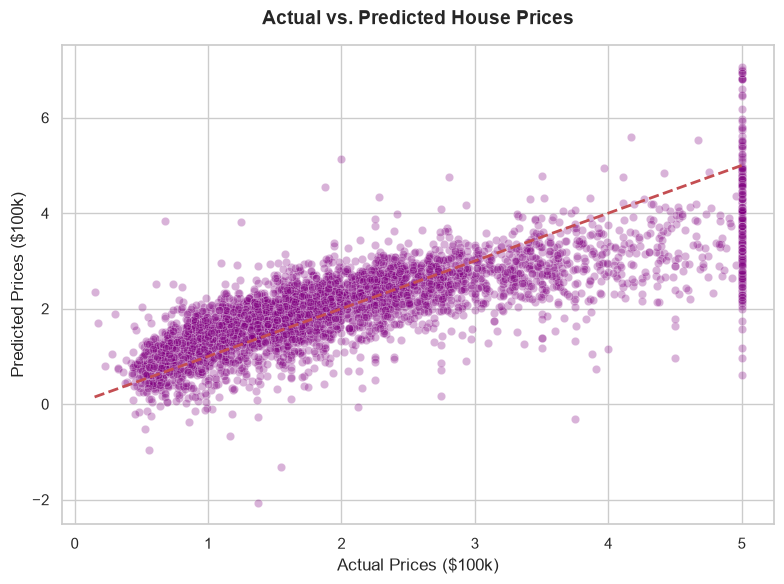

In [13]:
# STEP 5: VISUALIZATIONS
print("Generating Performance Visualizations...")

# Plot Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted House Prices', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Prices ($100k)', fontsize=12)
plt.ylabel('Predicted Prices ($100k)', fontsize=12)
plt.tight_layout()
plt.show()  

/var/folders/s1/j7hjl2rj1lg257133mbhmpt00000gn/T/ipykernel_81212/2406233617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coefficients.values, y=coefficients.index, palette='coolwarm')


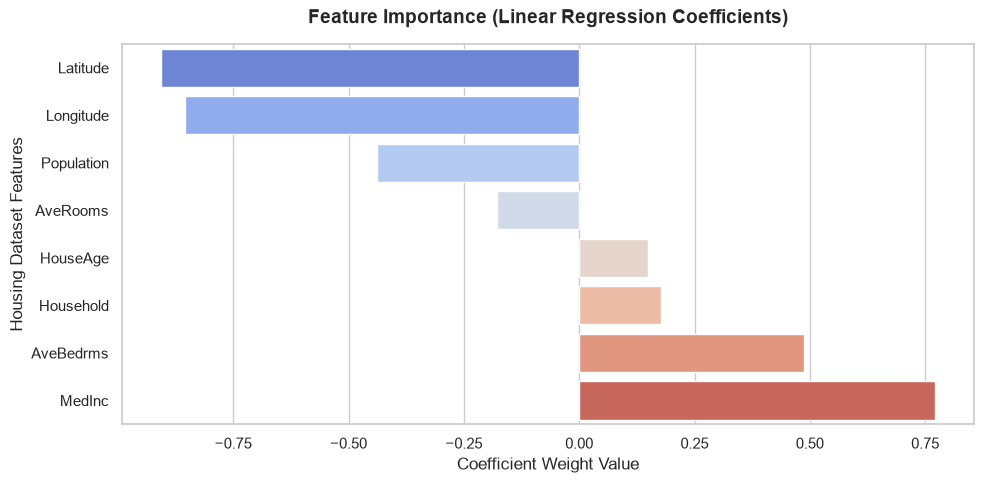

In [14]:
# Plot Feature Importances
coefficients = pd.Series(model.coef_, index=X.columns).sort_values()
plt.figure(figsize=(10, 5))
sns.barplot(x=coefficients.values, y=coefficients.index, palette='coolwarm')
plt.title('Feature Importance (Linear Regression Coefficients)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient Weight Value', fontsize=12)
plt.ylabel('Housing Dataset Features', fontsize=12)
plt.tight_layout()
plt.show() 